# NSynth relative pitch triplet demo

This notebook builds a small contrastive-style triplet sampler on NSynth validation clips. Each example is an interval made from two notes (start → target). Anchor, positive, and negative share the same instrument; positive and negative are transposed by the same amount relative to the anchor. Positive uses the same interval size as the anchor, while the negative uses a different interval size (tracked for analysis). Notes are trimmed to 400 ms with a cosine fade-out, and each 2-note clip is exactly 2.0 s.


In [1]:
import json
import math
import random
from collections import defaultdict
from pathlib import Path
from typing import Dict, List, Tuple

import torch
import torchaudio
import torch.nn.functional as F
import pandas as pd

from IPython.display import Audio, display

%matplotlib inline
import matplotlib.pyplot as plt

import seaborn as sns
import numpy as np

from tqdm.auto import tqdm

from lightning_scripts.nsynth_triplet_dataset import NsynthTripletDataset

# Zero-shot interval match experiment

In [2]:
def midi2hz(midi: int) -> float:
    return 440.0 * 2 ** ((midi - 69) / 12.0)

def hz2midi(hz: float) -> int:
    return 69 + 12.0 * np.log2(hz / 440.0)



print(f"Using {midi2hz(40):.2f} Hz and {midi2hz(80):.2f} Hz as min/max MIDI for triplet dataset")

Using 82.41 Hz and 830.61 Hz as min/max MIDI for triplet dataset


## Load pretrained models


In [ ]:
# Device and target sample rate for generated clips
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_SR = 20_000

# Load 6 pretrained models
import importlib
from lightning_scripts.utils import model_build_utils
importlib.reload(model_build_utils)
from lightning_scripts.utils.model_build_utils import get_model

ssl_invar_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01.yaml")
ssl_equi_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01.yaml")
ssl_scaled_invar_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only.yaml")
ssl_scaled_equi_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only.yaml")
word_config = Path("model_configs/supervised_models/word_kell2018_MatchedDataset_LARS.yaml")
audioset_config = Path("model_configs/supervised_models/audioset_kell2018_MatchedDataset_LARS.yaml")
multitask_config = Path("model_configs/supervised_models/kell2018_word_speaker_audioset_MatchedDataset_LARS.yaml")
unbal_audioset_config = Path("model_configs/supervised_models/kell2018_audioset_unbalanced_supervised.yaml")

models = {
    "ssl_invar": get_model(ssl_invar_config, layer_out="relu4"),
    "ssl_equi": get_model(ssl_equi_config, layer_out="relu4"),
    "ssl_scaled_invar": get_model(ssl_scaled_invar_config, layer_out="relu4"),
    "ssl_scaled_equi": get_model(ssl_scaled_equi_config, layer_out="relu4"),
    "word": get_model(word_config, supervised=True, layer_out="relu4"),
    "audioset": get_model(audioset_config, supervised=True, layer_out="relu4"),
    "multitask": get_model(multitask_config, supervised=True, layer_out="relu4"),
    "unbal_audioset": get_model(unbal_audioset_config, supervised=True, layer_out="relu4"),
}

for m in models.values():
    m.eval().to(DEVICE)

print(f"Loaded {len(models)} models on {DEVICE}")



Loaded 8 models on cuda


In [11]:
## Init common colors and plot names 
ssl_base_palette  = sns.color_palette("Greens", n_colors=6) 
palette = {
    "multitask": "grey",
    "audioset": "orange",
    "unbal_audioset": "red",
    "word": "blue",
    "ssl_scaled_invar": "olive",
    "ssl_scaled_equi": "gold",
    "ssl_invar": ssl_base_palette[0],
    "ssl_equi": ssl_base_palette[-1],
}




model_labels = [
    "jsin multi-task supervised",
    "unbalanced audioset supervised",
    "jsin audioset supervised",
    "jsin word supervised",
    "scaled ssl invar",
    "scaled ssl equi",
    "ssl invar",
    "ssl equi",
]

model_name_dict = {
    "multitask": "jsin multi-task supervised",
    "unbal_audioset": "unbalanced audioset supervised",
    "audioset": "jsin audioset supervised",
    "word": "jsin word supervised",
    "ssl_scaled_invar": "scaled ssl invar",
    "ssl_scaled_equi": "scaled ssl equi",
    "ssl_invar": "ssl invar",
    "ssl_equi": "ssl equi",
}


In [4]:
def encode_audio(model, audio_batch: torch.Tensor) -> torch.Tensor:
    model.eval()
    with torch.no_grad():
        z = model(audio_batch)
        if z.ndim > 2:
            z = z.flatten(start_dim=1)
    return z


def distance_metrics_on_triplet(model, clips: Dict[str, torch.Tensor], sr: int) -> Dict[str, float]:
    """Compute simple L2 distances between anchor-positive and anchor-negative."""
    waves = {}
    for k, v in clips.items():
        w = v
        if sr != MODEL_SR:
            w = torchaudio.functional.resample(w.unsqueeze(0), sr, MODEL_SR).squeeze(0)
        waves[k] = w.to(DEVICE)

    # Encode each example separately -- do not pair batch
    anchor_batch = waves["anchor"].unsqueeze(0).unsqueeze(1)
    positive_batch = waves["positive"].unsqueeze(0).unsqueeze(1)
    negative_batch = waves["negative"].unsqueeze(0).unsqueeze(1)

    z_anchor = encode_audio(model, anchor_batch)
    z_pos = encode_audio(model, positive_batch)
    z_neg = encode_audio(model, negative_batch)

    pos_l2 = torch.norm(z_anchor - z_pos, p=2).item()
    neg_l2 = torch.norm(z_anchor - z_neg, p=2).item()

    return {
        "pos_l2": pos_l2,
        "neg_l2": neg_l2,
        "judgement_pos_lt_neg": int(pos_l2 < neg_l2),
    }





# Zero-shot interval match task

In [8]:
# Instantiate dataset and dataloader
triplet_ds = NsynthTripletDataset(n_examples=1000,
                                  seed=123,
                                  min_midi=30,
                                  max_midi=80,
                                  max_interval=6,
                                  experiment_type = "interval_match",
                                  balance_eval=True,
)

def nsynth_triplet_collate(batch):
    clips, sr, triplet = batch[0]
    return clips, sr, triplet

triplet_loader = torch.utils.data.DataLoader(
    triplet_ds, batch_size=1, shuffle=False, collate_fn=nsynth_triplet_collate
)
print(f"Triplet dataset ready: {len(triplet_ds)} examples at target_sr={triplet_ds.target_sr}")


# Demo: draw one triplet from the dataset and listen
sample_clips, sample_sr, sample_triplet = triplet_ds[0]
NsynthTripletDataset.describe_triplet(sample_triplet)
for role in ("anchor", "positive", "negative"):
    display(Audio(sample_clips[role].numpy(), rate=sample_sr))


Triplet dataset ready: 960 examples at target_sr=20000
Anchor   | instrument_str vocal_acoustic_000 |  60 →  54 (Δ -6) | ids vocal_acoustic_000-060-100 → vocal_acoustic_000-054-050
Positive | instrument_str vocal_acoustic_000 |  69 →  63 (Δ -6) | ids vocal_acoustic_000-069-075 → vocal_acoustic_000-063-075
Negative | instrument_str vocal_acoustic_000 |  69 →  70 (Δ +1) | ids vocal_acoustic_000-069-075 → vocal_acoustic_000-070-050


In [9]:
# Evaluate 6 models on 300 triplets and collect simple L2 stats
all_results = []
for batch_idx, (clips, sr, triplet) in tqdm(
    enumerate(triplet_loader), total=len(triplet_loader), desc="Evaluating triplets"
):
    for name, model in models.items():
        sr_val = int(sr)
        interval = triplet["anchor"]["interval"]
        interval_size = abs(interval)
        negative_interval = triplet["negative"]["interval"]
        negative_interval_size = triplet["negative"].get("interval_size", abs(negative_interval))
        instrument = triplet["anchor"]["instrument"]
        metrics = distance_metrics_on_triplet(model, clips, sr_val)
        metrics.update(
            {
                "model": name,
                "batch_idx": batch_idx,
                "interval": interval,
                "interval_size": interval_size,
                "negative_interval": negative_interval,
                "negative_interval_size": negative_interval_size,
                "neg_vs_anchor": "neg_gt_anchor" if negative_interval_size > interval_size else "neg_lt_anchor",
                "instrument": instrument,
            }
        )
        all_results.append(metrics)

results_df = pd.DataFrame(all_results)
display(results_df.head())


Evaluating triplets:   0%|          | 0/960 [00:00<?, ?it/s]

,pos_l2,neg_l2,judgement_pos_lt_neg,model,batch_idx,interval,interval_size,negative_interval,negative_interval_size,neg_vs_anchor,instrument
0,14.879392,14.363543,0,ssl_invar,0,-6,6,1,1,neg_lt_anchor,vocal_acoustic_000
1,16.406239,16.381388,0,ssl_equi,0,-6,6,1,1,neg_lt_anchor,vocal_acoustic_000
2,255.974747,273.726471,1,ssl_scaled_invar,0,-6,6,1,1,neg_lt_anchor,vocal_acoustic_000
3,214.031982,226.818604,1,ssl_scaled_equi,0,-6,6,1,1,neg_lt_anchor,vocal_acoustic_000
4,523.673828,456.607819,0,word,0,-6,6,1,1,neg_lt_anchor,vocal_acoustic_000


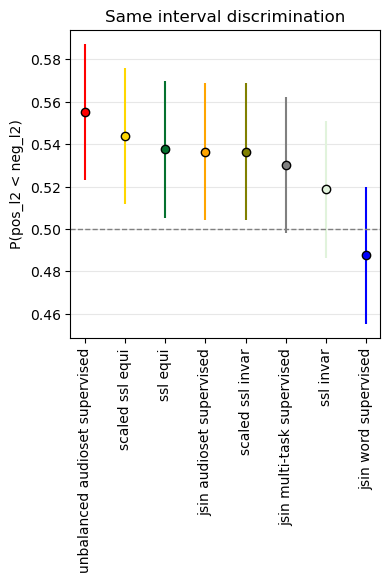

/tmp/ipykernel_230662/3539354362.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(axes.get_xticklabels(), rotation=90, ha="center")


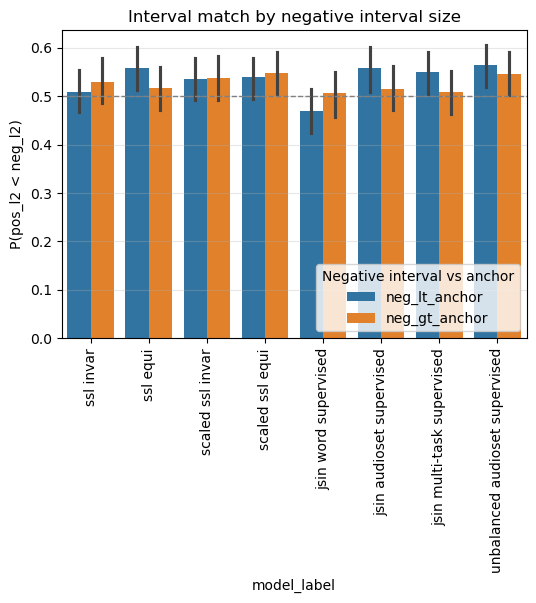

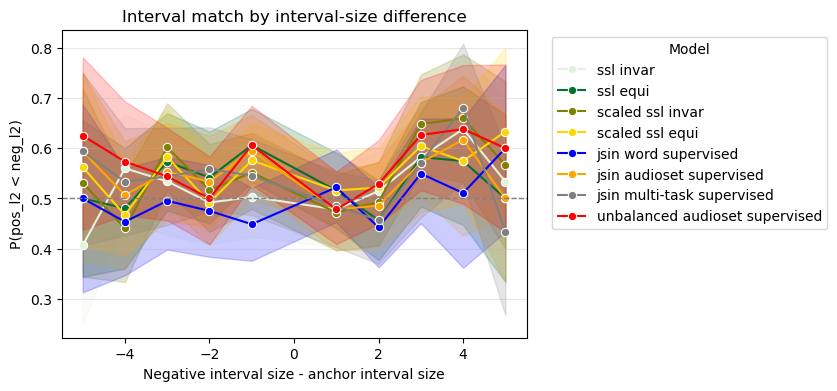

In [12]:
# Plot aggregate results
results_df['family'] = results_df['instrument'].str.split('_').str[0]
judgement_rate = results_df.groupby("model")["judgement_pos_lt_neg"].mean()
# sort by judgement rate

judgement_rate = judgement_rate.sort_values(ascending=False)

fig, axes = plt.subplots(1, 1, figsize=(4, 4))
models_order = judgement_rate.index

for i, model in enumerate(models_order):
    mean_loss = results_df[results_df.model == model]["judgement_pos_lt_neg"].mean()
    error = 2 * results_df[results_df.model == model]["judgement_pos_lt_neg"].std() / np.sqrt(len(results_df[results_df.model == model]))
    axes.errorbar(
        [i],
        [mean_loss],
        fmt='o',
        yerr=error,
        label=model,
        color=palette.get(model, "gray"),
        markeredgecolor="k",
    )


xtick_labels = [model_name_dict[model] for model in models_order]
axes.set_xticks(range(len(models_order)))
axes.set_xticklabels(xtick_labels, rotation=90, ha='center')
# axes.set_yticks(np.linspace(0.5, 1, 5))
axes.axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes.set_ylabel("P(pos_l2 < neg_l2)")
axes.set_title("Same interval discrimination")
axes.grid(True, axis="y", alpha=0.3)
plt.show()

# Plot by negative interval size relative to anchor
plot_df = results_df.copy()
plot_df["model_label"] = plot_df["model"].map(model_name_dict)
fig, axes = plt.subplots(1, 1, figsize=(6, 4))
sns.barplot(
    data=plot_df,
    x="model_label",
    y="judgement_pos_lt_neg",
    hue="neg_vs_anchor",
    ax=axes,
)
axes.axhline(0.5, color="gray", linestyle="--", linewidth=1)
axes.set_ylabel("P(pos_l2 < neg_l2)")
axes.set_title("Interval match by negative interval size")
axes.set_xticklabels(axes.get_xticklabels(), rotation=90, ha="center")
axes.grid(True, axis="y", alpha=0.3)
axes.legend(title="Negative interval vs anchor", loc="lower right")
plt.show()

# Plot performance by signed interval size difference (negative - anchor)
rank_df = results_df.copy()
rank_df["interval_diff_size"] = rank_df["negative_interval_size"] - rank_df["interval_size"]
rank_df["model_label"] = rank_df["model"].map(model_name_dict)
label_palette = {model_name_dict[k]: v for k, v in palette.items() if k in model_name_dict}

fig, axes = plt.subplots(1, 1, figsize=(6, 4))
sns.lineplot(
    data=rank_df,
    x="interval_diff_size",
    y="judgement_pos_lt_neg",
    hue="model_label",
    palette=label_palette,
    marker="o",
    ax=axes,
)
axes.axhline(0.5, color="gray", linestyle="--", linewidth=1)
axes.set_xlabel("Negative interval size - anchor interval size")
axes.set_ylabel("P(pos_l2 < neg_l2)")
axes.set_title("Interval match by interval-size difference")
axes.grid(True, axis="y", alpha=0.3)
axes.legend(title="Model", bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()

# plt.figure(figsize=(8, 4))
# results_df.boxplot(column=["pos_l2", "neg_l2"], by="model", rot=90)
# # plt.suptitle("")
# plt.suptitle("L2 distances by model")
# plt.grid(True, axis="y", alpha=0.3)
# plt.show()


# Zero-shot direction match task - same instrument and interval, different midi for positive

In [15]:
# Instantiate dataset and dataloader
direction_df = NsynthTripletDataset(n_examples=1000, seed=42, min_midi=30, max_midi=90, experiment_type="direction_transpose", balance_eval=True)

def nsynth_triplet_collate(batch):
    clips, sr, triplet = batch[0]
    return clips, sr, triplet

direction_loader = torch.utils.data.DataLoader(
    direction_df, batch_size=1, shuffle=False, collate_fn=nsynth_triplet_collate
)
print(f"Triplet dataset ready: {len(direction_df)} examples at target_sr={direction_df.target_sr}")

all_results = []
for batch_idx, (clips, sr, triplet) in tqdm(enumerate(direction_loader), total=len(direction_loader), desc="Evaluating triplets"):
    for name, model in models.items():
        sr_val = int(sr)
        interval = triplet["anchor"]["interval"]
        instrument = triplet["anchor"]["instrument"]
        metrics = distance_metrics_on_triplet(model, clips, sr_val)
        metrics.update({"model": name, "batch_idx": batch_idx, "interval": interval, "instrument": instrument})
        all_results.append(metrics)

direction_match_results_df = pd.DataFrame(all_results)
display(direction_match_results_df.head())


Triplet dataset ready: 960 examples at target_sr=20000


Evaluating triplets:   0%|          | 0/960 [00:00<?, ?it/s]

,pos_l2,neg_l2,judgement_pos_lt_neg,model,batch_idx,interval,instrument
0,11.344978,12.132012,1,ssl_invar,0,-7,keyboard_electronic_001
1,17.391109,17.047878,0,ssl_equi,0,-7,keyboard_electronic_001
2,304.985413,304.129272,0,ssl_scaled_invar,0,-7,keyboard_electronic_001
3,276.454712,280.797913,1,ssl_scaled_equi,0,-7,keyboard_electronic_001
4,487.629974,502.729980,1,word,0,-7,keyboard_electronic_001


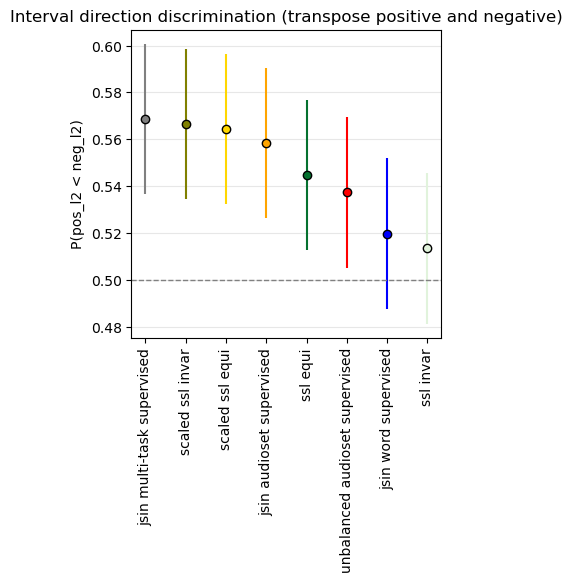

In [16]:
judgement_rate = direction_match_results_df.groupby("model")["judgement_pos_lt_neg"].mean()
# sort by judgement rate
judgement_rate = judgement_rate.sort_values(ascending=False)

fig, axes = plt.subplots(1, 1, figsize=(4, 4))
models_order = judgement_rate.index

for i, model in enumerate(models_order):

    mean_loss = direction_match_results_df[direction_match_results_df.model == model]["judgement_pos_lt_neg"].mean()   
    error = 2 * direction_match_results_df[direction_match_results_df.model == model]["judgement_pos_lt_neg"].std() / np.sqrt(len(direction_match_results_df[direction_match_results_df.model == model]))
    axes.errorbar(
        [i],
        [mean_loss],
        fmt='o',
        yerr=error,
        label=model,
        color=palette[model],
        markeredgecolor="k",
    )

xtick_labels = [model_name_dict[model] for model in models_order]

axes.set_xticks(range(len(xtick_labels)))
axes.set_xticklabels(xtick_labels, rotation=90, ha='center')
# axes.set_yticks(np.linspace(0, 1, 5))
# axes.set_ylim(0.5, 1)
axes.axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes.set_ylabel("P(pos_l2 < neg_l2)")
axes.set_title("Interval direction discrimination (transpose positive and negative)")
axes.grid(True, axis="y", alpha=0.3)
plt.show()

# Zero-shot interval direction task - same insturment, interval direction of positive is same as anchor

In [81]:
# reload the triplet dataset
from importlib import reload
from lightning_scripts import nsynth_triplet_dataset
reload(nsynth_triplet_dataset)
from lightning_scripts.nsynth_triplet_dataset import NsynthTripletDataset


In [32]:
direction_df = NsynthTripletDataset(n_examples=100, seed=42, min_midi=30, max_midi=90, max_interval=6, experiment_type="direction_match", balance_eval=True)

example, sampling_rate, metadata = direction_df[0]
display(Audio(example["anchor"], rate=sampling_rate))
display(Audio(example["positive"], rate=sampling_rate))
display(Audio(example["negative"], rate=sampling_rate))


Triplet dataset ready: 1920 examples at target_sr=20000


Evaluating triplets:   0%|          | 0/1920 [00:00<?, ?it/s]

,pos_l2,neg_l2,judgement_pos_lt_neg,model,batch_idx,interval,instrument
0,2.421168,7.359611,1,ssl_invar,0,-7,guitar_electronic_022
1,4.861027,11.061230,1,ssl_equi,0,-7,guitar_electronic_022
2,68.887413,166.030899,1,ssl_scaled_invar,0,-7,guitar_electronic_022
3,75.548775,202.726288,1,ssl_scaled_equi,0,-7,guitar_electronic_022
4,136.745926,240.180038,1,word,0,-7,guitar_electronic_022


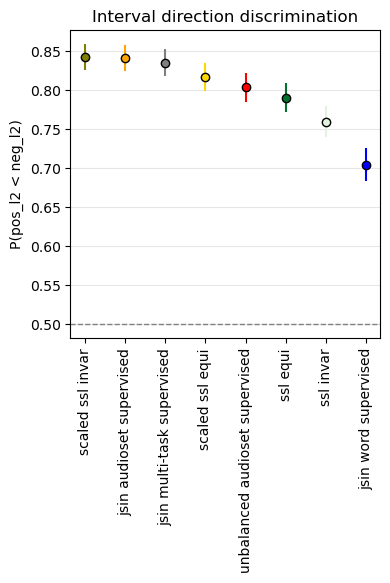

In [89]:
# Instantiate dataset and dataloader
direction_df = NsynthTripletDataset(n_examples=2000, seed=42, min_midi=30, max_midi=90, max_interval=12, experiment_type="direction_match", balance_eval=True)

def nsynth_triplet_collate(batch):
    clips, sr, triplet = batch[0]
    return clips, sr, triplet

direction_loader = torch.utils.data.DataLoader(
    direction_df, batch_size=1, shuffle=False, collate_fn=nsynth_triplet_collate
)
print(f"Triplet dataset ready: {len(direction_df)} examples at target_sr={direction_df.target_sr}")

all_results = []
for batch_idx, (clips, sr, triplet) in tqdm(enumerate(direction_loader), total=len(direction_loader), desc="Evaluating triplets"):
    for name, model in models.items():
        sr_val = int(sr)
        interval = triplet["anchor"]["interval"]
        instrument = triplet["anchor"]["instrument"]
        metrics = distance_metrics_on_triplet(model, clips, sr_val)
        metrics.update({"model": name, "batch_idx": batch_idx, "interval": interval, "instrument": instrument})
        all_results.append(metrics)

direction_match_results_df = pd.DataFrame(all_results)
display(direction_match_results_df.head())

judgement_rate = direction_match_results_df.groupby("model")["judgement_pos_lt_neg"].mean()
# sort by judgement rate
judgement_rate = judgement_rate.sort_values(ascending=False)

fig, axes = plt.subplots(1, 1, figsize=(4, 4))
models_order = judgement_rate.index

for i, model in enumerate(models_order):

    mean_loss = direction_match_results_df[direction_match_results_df.model == model]["judgement_pos_lt_neg"].mean()   
    error = 2 * direction_match_results_df[direction_match_results_df.model == model]["judgement_pos_lt_neg"].std() / np.sqrt(len(direction_match_results_df[direction_match_results_df.model == model]))
    axes.errorbar(
        [i],
        [mean_loss],
        fmt='o',
        yerr=error,
        label=model,
        color=palette[model],
        markeredgecolor="k",
    )

xtick_labels = [model_name_dict[model] for model in models_order]

axes.set_xticks(range(len(xtick_labels)))
axes.set_xticklabels(xtick_labels, rotation=90, ha='center')
# axes.set_yticks(np.linspace(0, 1, 5))
# axes.set_ylim(0.5, 1)
axes.axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes.set_ylabel("P(pos_l2 < neg_l2)")
axes.set_title("Interval direction discrimination")
axes.grid(True, axis="y", alpha=0.3)
plt.show()


# Zero-shot interval match task - Melody match

Triplet dataset ready: 1920 examples at target_sr=20000


Evaluating triplets:   0%|          | 0/1920 [00:00<?, ?it/s]

,pos_l2,neg_l2,judgement_pos_lt_neg,model,batch_idx,interval,instrument,negative_interval,interval_diff
0,7.722367,9.473685,1,ssl_invar,0,-7,guitar_electronic_022,7,14
1,8.361572,12.003901,1,ssl_equi,0,-7,guitar_electronic_022,7,14
2,172.208984,205.386185,1,ssl_scaled_invar,0,-7,guitar_electronic_022,7,14
3,178.814804,232.352478,1,ssl_scaled_equi,0,-7,guitar_electronic_022,7,14
4,578.016602,578.524536,1,word,0,-7,guitar_electronic_022,7,14


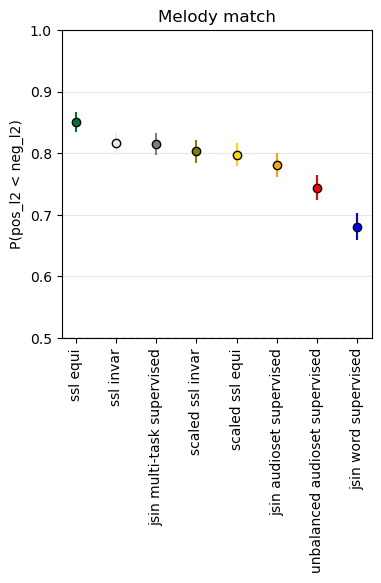

In [17]:
# Instantiate dataset and dataloader
direction_df = NsynthTripletDataset(n_examples=2000, seed=42, min_midi=30, max_midi=90, experiment_type="timbre_order_match", balance_eval=True)

def nsynth_triplet_collate(batch):
    clips, sr, triplet = batch[0]
    return clips, sr, triplet

direction_loader = torch.utils.data.DataLoader(
    direction_df, batch_size=1, shuffle=False, collate_fn=nsynth_triplet_collate
)
print(f"Triplet dataset ready: {len(direction_df)} examples at target_sr={direction_df.target_sr}")

all_results = []
for batch_idx, (clips, sr, triplet) in tqdm(enumerate(direction_loader), total=len(direction_loader), desc="Evaluating triplets"):
    for name, model in models.items():
        sr_val = int(sr)
        interval = triplet["anchor"]["interval"]
        negative_interval = triplet["negative"]["interval"]
        interval_diff = negative_interval - interval
        instrument = triplet["anchor"]["instrument"]

        metrics = distance_metrics_on_triplet(model, clips, sr_val)
        metrics.update({"model": name, "batch_idx": batch_idx, "interval": interval, "instrument": instrument, "negative_interval": negative_interval, "interval_diff": interval_diff})
        all_results.append(metrics)

timbre_order_match_df = pd.DataFrame(all_results)
display(timbre_order_match_df.head())
judgement_rate = timbre_order_match_df.groupby("model")["judgement_pos_lt_neg"].mean()
# sort by judgement rate
judgement_rate = judgement_rate.sort_values(ascending=False)

fig, axes = plt.subplots(1, 1, figsize=(4, 4))
models_order = judgement_rate.index

for i, model in enumerate(models_order):

    mean_loss = timbre_order_match_df[timbre_order_match_df.model == model]["judgement_pos_lt_neg"].mean()   
    error = 2 * timbre_order_match_df[timbre_order_match_df.model == model]["judgement_pos_lt_neg"].std() / np.sqrt(len(timbre_order_match_df[timbre_order_match_df.model == model]))
    axes.errorbar(
        [i],
        [mean_loss],
        fmt='o',
        yerr=error,
        label=model,
        color=palette[model],
        markeredgecolor="k",
    )

xtick_labels = [model_name_dict[model] for model in models_order]

axes.set_xticks(range(len(xtick_labels)))
axes.set_xticklabels(xtick_labels, rotation=90, ha='center')
# axes.set_yticks(np.linspace(0, 1, 5))
axes.set_ylim(0.5, 1)
axes.axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes.set_ylabel("P(pos_l2 < neg_l2)")
axes.set_title("Melody match")
axes.grid(True, axis="y", alpha=0.3)
plt.show()

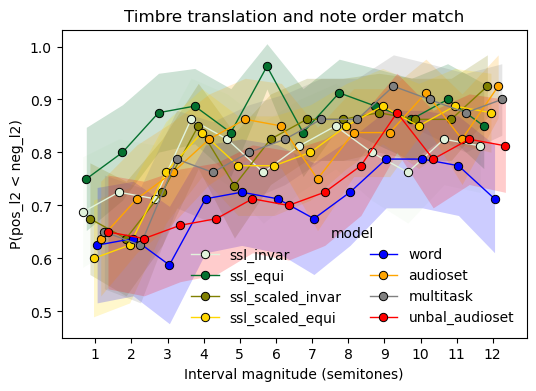

In [88]:
# plot judgement rate by interval magnitude with models as hue
plot_df = timbre_order_match_df.copy()
plot_df["interval_abs"] = plot_df["interval"].abs()
interval_order = sorted(plot_df["interval_abs"].unique())
palette_dict = {k: palette[k] for k in plot_df["model"].unique() if k in palette}

summary = (
    plot_df
    .groupby(["model", "interval_abs"], as_index=False)["judgement_pos_lt_neg"]
    .agg(["mean", "count", "std"])
    .reset_index()
)
summary["se"] = summary["std"] / summary["count"].pow(0.5)

fig, ax = plt.subplots(figsize=(6, 4))
models_order = [m for m in plot_df["model"].unique() if m in palette_dict]

n_models = len(models_order)
if n_models == 0:
    raise ValueError("No models found for plotting")

tick_positions = list(range(len(interval_order)))
dodge = 0.8 / max(n_models, 1)

for idx, model in enumerate(models_order):
    model_df = summary[summary["model"] == model]
    model_df = model_df.set_index("interval_abs").reindex(interval_order).reset_index()
    x_vals = [pos - 0.4 + dodge / 2 + idx * dodge for pos in tick_positions]
    y_vals = model_df["mean"].to_numpy()
    y_err = 2 * model_df["se"].fillna(0).to_numpy()
    color = palette_dict.get(model, None)

    ax.fill_between(
        x_vals,
        y_vals - y_err,
        y_vals + y_err,
        color=color,
        alpha=0.2,
        linewidth=0,
    )
    ax.plot(
        x_vals,
        y_vals,
        marker="o",
        linestyle="-",
        linewidth=1,
        color=color,
        markeredgecolor="black",
        markeredgewidth=0.7,
        label=model,
    )

ax.set_xlabel("Interval magnitude (semitones)")
ax.set_ylabel("P(pos_l2 < neg_l2)")
ax.set_title("Timbre translation and note order match")
ax.set_xticks(tick_positions)
ax.set_xticklabels(interval_order)
ax.legend(title="model", frameon=False, ncol=2)


# Zero-shot instrument classification

Anchor and positive share the same instrument but different MIDI notes. Negative uses a different instrument but the same MIDI note as positive.

In [69]:
from importlib import reload
from lightning_scripts import nsynth_triplet_dataset
reload(nsynth_triplet_dataset)
from lightning_scripts.nsynth_triplet_dataset import NsynthTripletDataset

In [70]:
# Instantiate dataset and dataloader
instrument_df = NsynthTripletDataset(n_examples=1000, seed=42, min_midi=30, max_midi=90, experiment_type="instrument_match")

def nsynth_triplet_collate(batch):
    clips, sr, triplet = batch[0]
    return clips, sr, triplet

instrument_loader = torch.utils.data.DataLoader(
    instrument_df, batch_size=1, shuffle=False, collate_fn=nsynth_triplet_collate
)
print(f"Triplet dataset ready: {len(instrument_df)} examples at target_sr={instrument_df.target_sr}")

all_results = []
for batch_idx, (clips, sr, triplet) in tqdm(enumerate(instrument_loader), total=len(instrument_loader), desc="Evaluating triplets"):
    for name, model in models.items():
        sr_val = int(sr)
        interval = triplet["anchor"]["interval"]
        instrument = triplet["anchor"]["instrument"]
        metrics = distance_metrics_on_triplet(model, clips, sr_val)
        metrics.update({"model": name, "batch_idx": batch_idx, "interval": interval, "instrument": instrument})
        all_results.append(metrics)

instrument_results_df = pd.DataFrame(all_results)
display(instrument_results_df.head())

Triplet dataset ready: 960 examples at target_sr=20000


Evaluating triplets:   0%|          | 0/960 [00:00<?, ?it/s]

,pos_l2,neg_l2,judgement_pos_lt_neg,model,batch_idx,interval,instrument
0,8.798549,8.111460,0,ssl_invar,0,-7,keyboard_electronic_001
1,13.537344,12.019141,0,ssl_equi,0,-7,keyboard_electronic_001
2,205.369583,206.511398,1,ssl_scaled_invar,0,-7,keyboard_electronic_001
3,217.997879,251.771973,1,ssl_scaled_equi,0,-7,keyboard_electronic_001
4,349.827820,421.130280,1,word,0,-7,keyboard_electronic_001


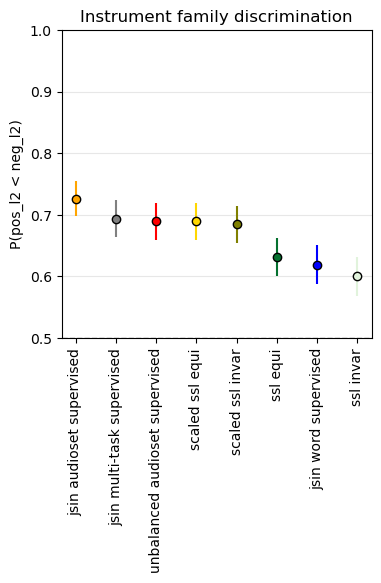

In [78]:
judgement_rate = instrument_results_df.groupby("model")["judgement_pos_lt_neg"].mean()
# sort by judgement rate
judgement_rate = judgement_rate.sort_values(ascending=False)

fig, axes = plt.subplots(1, 1, figsize=(4, 4))
models_order = judgement_rate.index

for i, model in enumerate(models_order):

    mean_loss = instrument_results_df[instrument_results_df.model == model]["judgement_pos_lt_neg"].mean()   
    error = 2 * instrument_results_df[instrument_results_df.model == model]["judgement_pos_lt_neg"].std() / np.sqrt(len(instrument_results_df[instrument_results_df.model == model]))
    axes.errorbar(
        [i],
        [mean_loss],
        fmt='o',
        yerr=error,
        label=model,
        color=palette[model],
        markeredgecolor="k",
    )

xtick_labels = [model_name_dict[model] for model in models_order]

axes.set_xticks(range(len(xtick_labels)))
axes.set_xticklabels(xtick_labels, rotation=90, ha='center')
# axes.set_yticks(np.linspace(0, 1, 5))
axes.set_ylim(0.5, 1)
axes.axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes.set_ylabel("P(pos_l2 < neg_l2)")
axes.set_title("Instrument family discrimination")
axes.grid(True, axis="y", alpha=0.3)
plt.show()